In [ ]:
Load the dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("C:\\Users\\Dell\\Downloads\\ipl match.csv")

df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,umpire1,umpire2
0,335982,2007/08,Bangalore,4/18/2008,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,4/19/2008,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,MR Benson,SL Shastri
2,335984,2007/08,Delhi,4/19/2008,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,4/20/2008,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,4/20/2008,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,BF Bowden,K Hariharan


In [ ]:
perform necessary data cleaning such as handling missing values and removing duplicates

In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("C:\\Users\\Dell\\Downloads\\ipl match.csv")

# Basic info
print(df.info())
print(df.isnull().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

# Handle missing values properly
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[cat_cols] = df[cat_cols].fillna("Unknown")
df[num_cols] = df[num_cols].fillna(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  umpire1       

In [ ]:
Explore the dataset to understand key patterns, distributions, and relationships between important variables.

In [3]:
# Describe dataset
print(df.describe())

# Unique teams
print(df['team1'].unique())

# Match count
print("Total Matches:", len(df))

                 id  result_margin  target_runs  target_overs
count  1.095000e+03    1095.000000  1095.000000   1095.000000
mean   9.048283e+05      16.959817   165.230137     19.705205
std    3.677402e+05      21.714792    34.487313      1.887000
min    3.359820e+05       0.000000     0.000000      0.000000
25%    5.483315e+05       5.000000   146.000000     20.000000
50%    9.809610e+05       8.000000   166.000000     20.000000
75%    1.254062e+06      19.000000   187.000000     20.000000
max    1.426312e+06     146.000000   288.000000     20.000000
['Royal Challengers Bangalore' 'Kings XI Punjab' 'Delhi Daredevils'
 'Mumbai Indians' 'Kolkata Knight Riders' 'Rajasthan Royals'
 'Deccan Chargers' 'Chennai Super Kings' 'Kochi Tuskers Kerala'
 'Pune Warriors' 'Sunrisers Hyderabad' 'Gujarat Lions'
 'Rising Pune Supergiants' 'Rising Pune Supergiant' 'Delhi Capitals'
 'Punjab Kings' 'Lucknow Super Giants' 'Gujarat Titans'
 'Royal Challengers Bengaluru']
Total Matches: 1095


In [ ]:
To identify the top performing teams based on the number of matches won.

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Gujarat Titans                  28
Punjab Kings                    24
Lucknow Super Giants            24
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Royal Challengers Bengaluru      7
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Unknown                          5
Name: count, dtype: int64


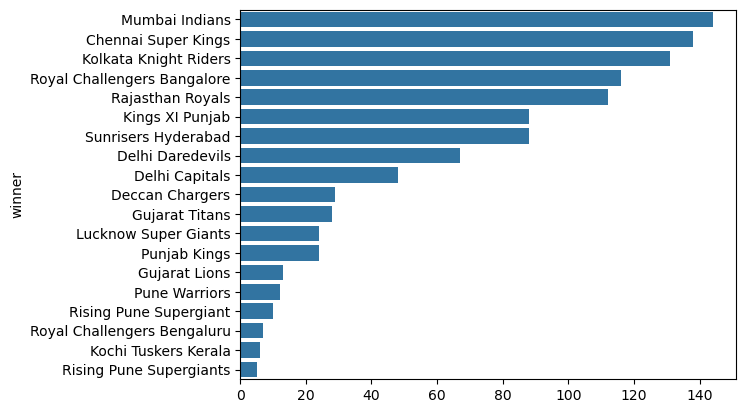

In [6]:
import matplotlib.pyplot as plt

team_wins = df['winner'].value_counts()

print(team_wins)

import seaborn as sns

df_filtered = df[df['winner'] != 'Unknown']

team_wins = df_filtered['winner'].value_counts()

sns.barplot(x=team_wins.values, y=team_wins.index)
plt.show()

In [ ]:
Understand whether teams prefer to bat or field after winning the toss and identify common strategies.

toss_decision
field    704
bat      391
Name: count, dtype: int64


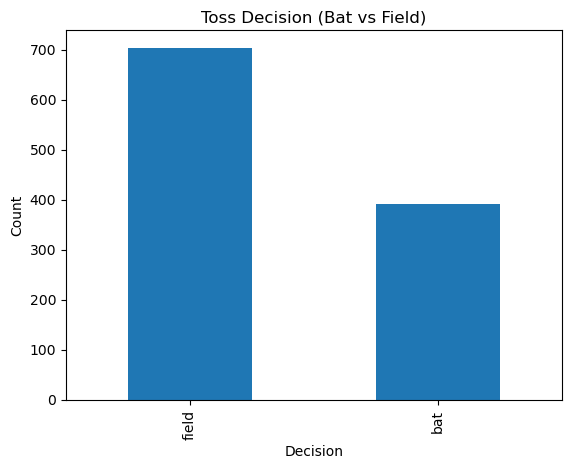

In [8]:
toss_decision = df['toss_decision'].value_counts()

print(toss_decision)

toss_decision.plot(kind='bar')
plt.title("Toss Decision (Bat vs Field)")
plt.xlabel("Decision")
plt.ylabel("Count")
plt.show()

In [ ]:
Analyze which venues host the most matches and observe patterns related to match locations.

venue
Eden Gardens                                  77
Wankhede Stadium                              73
M Chinnaswamy Stadium                         65
Feroz Shah Kotla                              60
Rajiv Gandhi International Stadium, Uppal     49
MA Chidambaram Stadium, Chepauk               48
Sawai Mansingh Stadium                        47
Dubai International Cricket Stadium           46
Wankhede Stadium, Mumbai                      45
Punjab Cricket Association Stadium, Mohali    35
Name: count, dtype: int64


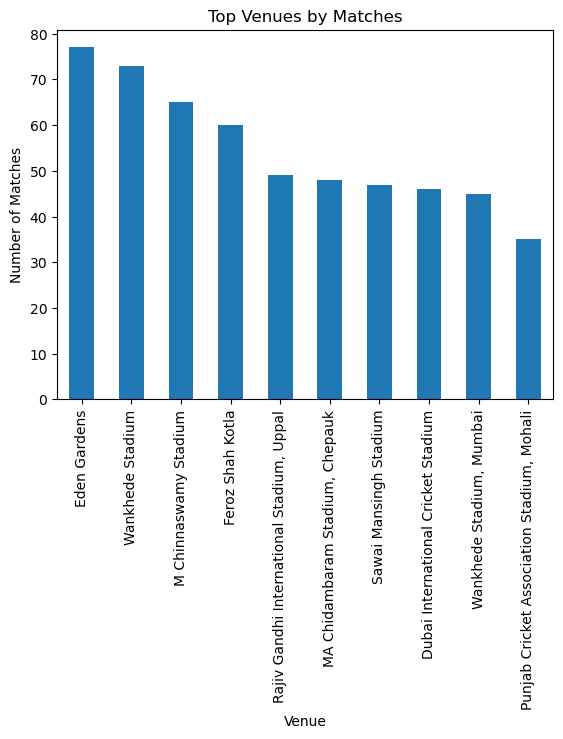

In [9]:
venue = df['venue'].value_counts().head(10)

print(venue)

venue.plot(kind='bar')
plt.title("Top Venues by Matches")
plt.xlabel("Venue")
plt.ylabel("Number of Matches")
plt.xticks(rotation=90)
plt.show()

In [ ]:
To analyze the relationships and correlations between different match factors such as toss result and match outcome.

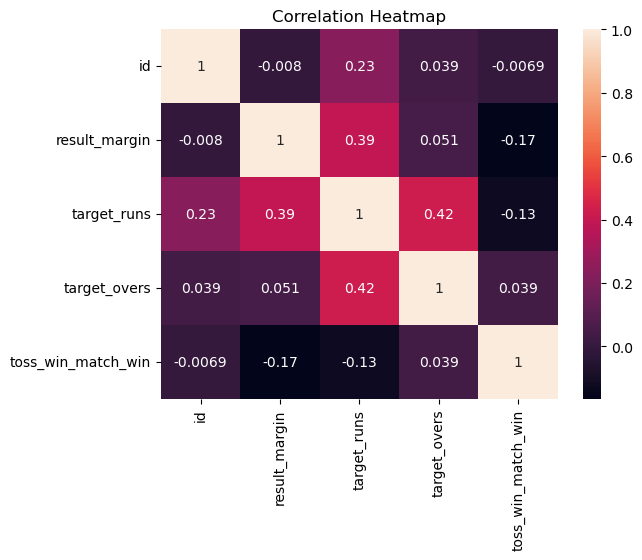

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert categorical to numeric (for heatmap)
df_encoded = df.copy()
df_encoded['toss_win_match_win'] = (df['toss_winner'] == df['winner']).astype(int)

sns.heatmap(df_encoded.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
To analyze the trend of matches played across different IPL seasons.

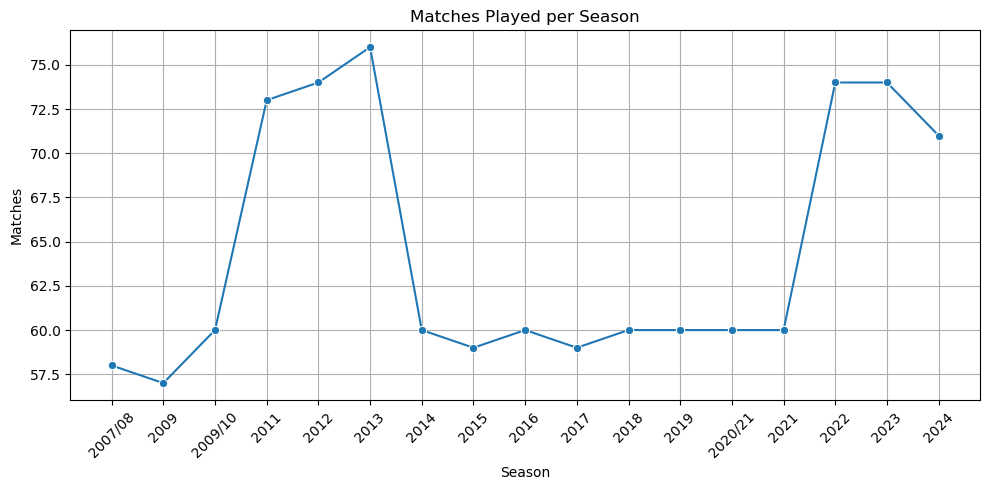

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count matches per season (sorted)
season_matches = df['season'].value_counts().sort_index()

plt.figure(figsize=(10,5))  # increase size

sns.lineplot(x=season_matches.index, y=season_matches.values, marker='o')

plt.title("Matches Played per Season")
plt.xlabel("Season")
plt.ylabel("Matches")

# Fix x-axis labels
plt.xticks(season_matches.index, rotation=45)

plt.grid(True)
plt.tight_layout()

plt.show()